In [1]:
import os, re, sys, glob, json, shutil, subprocess, tempfile
import numpy as np, cv2, pandas as pd
from scipy.ndimage import median_filter
import matplotlib; import matplotlib.pyplot as plt
from matplotlib.patches import Patch

PDF        = "../19series.pdf"
PAGES      = [1, 2, 3, 20, 70]
WORK       = "work"
OUT        = "outputs"
GRID_FT    = 10.0
INK_THRESH = 200
ELEV_LABEL_GUTTER = 134
DESPIKE_WIN, DESPIKE_PX = 9, 4.0
BURIED_RUN_FT, BURIED_DEPTH_FT = 25.0, 3.5
GAP_REFINE_FT, GAP_TOL_PX = 3.0, 7.0
GAP_WARN_FT = 5.0

os.makedirs(WORK, exist_ok=True); os.makedirs(OUT, exist_ok=True)
plt.rcParams.update({"figure.dpi": 110, "font.size": 9})
print("cv2", cv2.__version__, "| numpy", np.__version__, "| pandas", pd.__version__)
print("poppler:", "OK" if shutil.which("pdfimages") else "MISSING  (apt-get install poppler-utils)")
print("tesseract:", "OK" if shutil.which("tesseract") else "MISSING (datum will fall back to manual)")

cv2 5.0.0 | numpy 2.5.1 | pandas 3.0.5
poppler: OK
tesseract: OK


In [2]:
def extract_pages(pdf=PDF, pages=PAGES, work=WORK):
    """The PDF is a scan: every page is ONE embedded JPEG at its native size.
    pdfimages pulls that JPEG out losslessly - no resampling, no interpolation,
    which matters because every measurement below is made in pixels."""
    out = {}
    for p in pages:
        dst = os.path.join(work, f"page_{p:03d}.png")
        if not os.path.exists(dst):
            with tempfile.TemporaryDirectory() as td:
                subprocess.run(["pdfimages", "-f", str(p), "-l", str(p), "-png", pdf,
                                os.path.join(td, "im")], check=True)
                got = sorted(glob.glob(os.path.join(td, "im*.png")))
                if not got:
                    subprocess.run(["pdftoppm", "-f", str(p), "-l", str(p), "-r", "150",
                                    "-png", pdf, os.path.join(td, "im")], check=True)
                    got = sorted(glob.glob(os.path.join(td, "im*.png")))
                shutil.copy(got[0], dst)
        out[p] = dst
    return out

PAGE_FILES = extract_pages()
for p, f in PAGE_FILES.items():
    im = cv2.imread(f, 0)
    print(f"page {p}: {f}  {im.shape[1]} x {im.shape[0]} px   ink {(im<INK_THRESH).mean()*100:.2f}%")

page 1: work/page_001.png  4896 x 717 px   ink 4.92%
page 2: work/page_002.png  4896 x 721 px   ink 4.21%


page 3: work/page_003.png  4896 x 1212 px   ink 5.05%
page 20: work/page_020.png  4896 x 577 px   ink 5.07%


page 70: work/page_070.png  4896 x 924 px   ink 5.70%


In [3]:
def runs1d(a, tol=3):
    """Group a sorted index array into (start, end) runs, merging gaps <= tol."""
    if len(a) == 0: return []
    out, s, p = [], a[0], a[0]
    for v in a[1:]:
        if v - p > tol: out.append((int(s), int(p))); s = v
        p = v
    out.append((int(s), int(p)))
    return out

def dilate1d(v, k):
    """Binary dilation of a 1-D boolean vector by k samples each way."""
    out = v.copy()
    for s in range(1, k + 1):
        out[:-s] |= v[s:]; out[s:] |= v[:-s]
    return out

def detect_lattice(ink, frac=0.45):
    """Grid lines are the only strokes that run (almost) the full height / width.
    Returns run-groups of columns and rows that qualify."""
    H, W = ink.shape
    return (runs1d(np.where(ink.sum(0) > frac * H)[0]),
            runs1d(np.where(ink.sum(1) > frac * W)[0]))

def strip_grid(ink, V, H_, bridge=5):
    """Delete the lattice, then SURGICALLY repair the curves it was crossing.

    Naively zeroing a grid column also punches a hole through every data curve
    that crossed it, shattering each curve into ~140 px fragments.  So for each
    deleted band we re-connect only those rows where ink exists on BOTH sides
    within +-`bridge` px -- i.e. we restore continuity without restoring the grid."""
    m = ink.copy()
    for s, e in V:  m[:, max(0, s - 1):e + 2] = 0
    for s, e in H_: m[max(0, s - 1):e + 2, :] = 0
    for s, e in V:
        a, b = s - 2, e + 2
        if a < 0 or b >= m.shape[1]: continue
        both = dilate1d(m[:, a].astype(bool), bridge) & dilate1d(m[:, b].astype(bool), bridge)
        m[:, a + 1:b] |= both[:, None].astype(np.uint8)
    for s, e in H_:
        a, b = s - 2, e + 2
        if a < 0 or b >= m.shape[0]: continue
        both = dilate1d(m[a, :].astype(bool), bridge) & dilate1d(m[b, :].astype(bool), bridge)
        m[a + 1:b, :] |= both[None, :].astype(np.uint8)
    return m

def plot_axes(ink, V, r0, r1, pitch):
    """The two verticals bounding the plot are the ones carrying elevation tick
    stubs along the WHOLE height.  Scoring by ink volume alone gets fooled by a
    steep embankment; scoring by *vertical coverage* does not."""
    nb = max(4, int((r1 - r0) / (pitch / 5)))
    edges = np.linspace(r0, r1, nb + 1).astype(int)
    cov = lambda b: sum(1 for a, z in zip(edges[:-1], edges[1:]) if b[a:z].any()) / nb
    sc = []
    for s, e in V:
        if e - s + 1 > 4: continue
        sc.append(((s + e) / 2.0,
                   cov(ink[:, max(0, s - 13):max(0, s - 2)].max(1)),
                   cov(ink[:, e + 3:e + 14].max(1))))
    mid = np.median([c for c, _, _ in sc])
    return (max([x for x in sc if x[0] < mid], key=lambda t: t[2])[0],
            max([x for x in sc if x[0] > mid], key=lambda t: t[1])[0])

def _gutter_ocr(m, x0, y0, y1, psm, scale, ndig=3):
    crop = 255 - m[y0:y1, x0:x0 + ELEV_LABEL_GUTTER] * 255
    if (crop < 128).sum() < 20: return []
    crop = cv2.resize(crop, None, fx=scale, fy=scale, interpolation=cv2.INTER_CUBIC)
    crop = cv2.copyMakeBorder(crop, 40, 40, 40, 40, cv2.BORDER_CONSTANT, value=255)
    f = tempfile.mktemp(suffix=".png"); cv2.imwrite(f, crop)
    o = subprocess.run(["tesseract", f, "stdout", "tsv", "--psm", psm,
                        "-c", "tessedit_char_whitelist=0123456789"],
                       capture_output=True, text=True)
    os.unlink(f)
    out = []
    for ln in o.stdout.splitlines()[1:]:
        fl = ln.split("\t")
        t = (fl[11] or "").strip() if len(fl) >= 12 else ""
        if re.fullmatch(r"\d{%d}" % ndig, t) and int(t) % 10 == 0:
            out.append((y0 + (int(fl[7]) + int(fl[9]) / 2 - 40) / scale, int(t)))
    return out

def read_elev_labels(ink, V, H_, right_axis, lat_rows):
    """Read the RIGHT-hand elevation gutter (the left gutter's leading digit is
    overprinted by the sheet frame).  Two readers are pooled, because neither is
    reliable alone on a 1990s scan: one pass over the whole strip, and one tight
    crop per grid line.  Wrong readings are thrown out by consensus, not trusted."""
    if not shutil.which("tesseract"): return []
    m = ink.copy()
    for s_, e in V:  m[:, max(0, s_ - 1):e + 2] = 0
    for s_, e in H_: m[max(0, s_ - 1):e + 2, :] = 0
    m = cv2.morphologyEx(m, cv2.MORPH_CLOSE, np.ones((3, 3), np.uint8))
    x0 = int(right_axis) + 6
    pool = []
    for sc in (6, 8):
        pool += _gutter_ocr(m, x0, 0, m.shape[0], "6", sc)
    for r in lat_rows:
        a, b = int(r - 26), int(r + 26)
        if a < 0 or b > m.shape[0]: continue
        for psm in ("7", "8", "13"):
            for sc in (6, 8):
                pool += _gutter_ocr(m, x0, a, b, psm, sc)
    return pool

def fit_datum(pool, lat_rows, pitch):
    """Every label votes for one constant  C = elev + row / px_per_ft.  Snap each
    label to the grid line it annotates first -- OCR returns the row of the text,
    which sits ~15 px above that line and is worth 1.05 ft of bias if believed.
    Then keep the largest agreeing block and average it (RANSAC in one dimension)."""
    if not pool: return None, 0, 0
    ppf = pitch / GRID_FT; lat = np.asarray(lat_rows); votes = []
    for r, e in pool:
        j = int(np.argmin(abs(lat - r)))
        if abs(lat[j] - r) < pitch * 0.35: votes.append(e + lat[j] / ppf)
    if not votes: return None, 0, len(pool)
    best = max(votes, key=lambda c: sum(1 for k in votes if abs(k - c) < 0.5))
    inl = [c for c in votes if abs(c - best) < 0.5]
    if len(inl) < 2: return None, len(inl), len(votes)
    return float(np.mean(inl)), len(inl), len(votes)

def denoise(roi):
    """Drop annotation glyphs, traffic arrows and survey specks.  Discriminator is
    BOX FILL RATIO: a digit fills ~0.3-0.6 of its bounding box, a 2 px line
    through the same box fills < 0.15."""
    n, lab, st, _ = cv2.connectedComponentsWithStats(roi, 8)
    keep = np.zeros_like(roi); dropped = 0
    for k in range(1, n):
        x, y, w, h, a = st[k]; f = a / (w * h)
        if (8 <= w <= 70 and 10 <= h <= 55 and f >= 0.30) \
           or (a > 700 and f >= 0.35) or (a <= 12 and w <= 7 and h <= 7):
            dropped += 1; continue
        keep[lab == k] = 1
    return keep, dropped

def split_dash_solid(mask):
    """Existing ground is DASHED, the proposed template is SOLID.  Estimate the
    dash length from the component-width distribution and cut at 3x the median,
    so the threshold adapts to scan resolution instead of being hard-coded."""
    n, lab, st, _ = cv2.connectedComponentsWithStats(mask, 8)
    ws = np.array([st[k, cv2.CC_STAT_WIDTH] for k in range(1, n)])
    dash_w = float(np.median(ws)) if len(ws) else 12.0
    thr = max(40.0, 3.0 * dash_w)
    dash, solid = np.zeros_like(mask), np.zeros_like(mask)
    for k in range(1, n):
        w, h = st[k, cv2.CC_STAT_WIDTH], st[k, cv2.CC_STAT_HEIGHT]
        (solid if max(w, h) >= thr else dash)[lab == k] = 1
    return dash, solid, thr, dash_w

def candidates(mask, max_run=30):
    """Per column, the mid-point of every vertical ink run = a curve observation."""
    out = []
    for x in range(mask.shape[1]):
        col = np.where(mask[:, x])[0]; c = []
        for s, e in runs1d(col, tol=2):
            if e - s + 1 <= max_run: c.append((s + e) / 2.0)
            else: c += [float(s), float(e)]
        out.append(c)
    return out

def best_path(cands, reward=3.0, win=260, slope=0.6, slack=8.0, gap_pen=0.04):
    """Max-scoring chain through the candidate points (Viterbi over a DAG).

    A greedy left-to-right tracker breaks at the first long dash gap and then
    coasts away from the curve.  Scoring globally -- +reward per point used,
    -|dy| for roughness, -gap_pen per skipped column -- recovers the whole
    surface including the stretch hidden behind the proposed template."""
    pts = [(x, y) for x, c in enumerate(cands) for y in c]
    if not pts: return {}
    n = len(pts)
    xs = np.array([p[0] for p in pts]); ys = np.array([p[1] for p in pts])
    score = np.full(n, reward); prev = np.full(n, -1); start = 0
    for i in range(n):
        xi, yi = xs[i], ys[i]
        while xs[start] < xi - win: start += 1
        for j in range(start, i):
            dx = xi - xs[j]
            if dx <= 0: continue
            dy = abs(yi - ys[j])
            if dy > slope * dx + slack: continue
            s = score[j] + reward - dy - gap_pen * (dx - 1)
            if s > score[i]: score[i] = s; prev[i] = j
    k = int(np.argmax(score)); path = []
    while k >= 0: path.append(k); k = prev[k]
    return {int(xs[i]): float(ys[i]) for i in reversed(path)}

def snap_top(mask, chain, rad=9):
    """The template is drawn as a thin box (surface + pavement structure), so the
    finished surface is the TOPMOST stroke -- and we want that stroke's CENTRE.
    Taking its upper edge biases the whole surface up by half a stroke width,
    which is ~0.2 ft here and shows up directly as a fill/cut error."""
    out = {}
    for x, y in chain.items():
        lo, hi = max(0, int(y) - rad), min(mask.shape[0], int(y) + rad + 1)
        w = np.where(mask[lo:hi, x])[0]
        if len(w) == 0: out[x] = y; continue
        a, b = runs1d(w, tol=1)[0]
        out[x] = float(lo + (a + b) / 2.0)
    return out

def despike(y, win=None, thresh_px=None):
    """Reject outliers only -- do NOT smooth.  Leader lines, witness ticks and
    dimension arrows that survived the glyph filter show up as isolated jumps of
    5-8 px; genuine break-points (ditch invert, catch point, shoulder hinge) must
    come through untouched, so flagged samples are replaced by interpolation from
    their good neighbours rather than by a filtered value."""
    win = win or DESPIKE_WIN; thresh_px = thresh_px or DESPIKE_PX
    ok = ~np.isnan(y); idx = np.where(ok)[0]
    if len(idx) < win: return y, 0
    v = y[idx].copy()
    bad = np.abs(v - median_filter(v, size=win, mode="nearest")) > thresh_px
    if bad.any() and (~bad).sum() >= 2:
        v[bad] = np.interp(idx[bad], idx[~bad], v[~bad])
    out = y.copy(); out[idx] = v
    return out, int(bad.sum())

def trim_buried_tail(x, gpx, dpx, ppf):
    """Temporary pipes and other buried services run on past the template's toe.
    They read as a LONG, DEEP run of 'proposed below existing' that reaches the
    end of the chain -- a graded cut always closes back onto the ground inside
    the template, so it never looks like this.  Measured on this drawing set:
    real ditch cuts are <= 19 ft long and <= 3 ft deep, the temporary pipe at
    station 21+00 is 45 ft long and 6 ft deep."""
    ov = ~np.isnan(gpx) & ~np.isnan(dpx)
    if ov.sum() < 10: return dpx, []
    c = np.where(ov)[0]; xx = x[c]
    d = (gpx[c] - dpx[c]) / ppf
    sign = np.sign(np.where(np.abs(d) < 0.10, 0, d))
    runs, i = [], 0
    while i < len(d):
        if sign[i] < 0:
            j = i
            while j < len(d) and sign[j] <= 0: j += 1
            runs.append((i, j - 1, xx[j - 1] - xx[i], float(-d[i:j].min())))
            i = j
        else: i += 1
    out = dpx.copy(); killed = []
    for a, b, L, dep in runs:
        if L < BURIED_RUN_FT or dep < BURIED_DEPTH_FT: continue
        if xx[-1] - xx[b] <= 2.0:
            out[c[a]:] = np.nan; killed.append(dict(side="right", x_from=round(float(xx[a]), 2),
                                                    x_to=round(float(xx[-1]), 2),
                                                    run_ft=round(float(L), 1), depth_ft=round(dep, 2)))
        elif xx[a] - xx[0] <= 2.0:
            out[:c[b] + 1] = np.nan; killed.append(dict(side="left", x_from=round(float(xx[0]), 2),
                                                        x_to=round(float(xx[b]), 2),
                                                        run_ft=round(float(L), 1), depth_ft=round(dep, 2)))
    return out, killed

def refine_gaps(chain, full_mask, ppf, min_gap_ft=None, tol_px=None):
    """Inside a long interpolation gap the surface's own dashes usually still
    exist -- they were simply absorbed into a solid component they touch, so the
    dash/solid split never offered them.  Re-hunt for ink near the interpolated
    path in the FULL mask and accept it when it is close enough to be the same
    surface.  This is a recall pass, not a smoother: it only ever adds points."""
    min_gap_ft = min_gap_ft or GAP_REFINE_FT; tol_px = tol_px or GAP_TOL_PX
    if len(chain) < 2: return chain, 0
    xs = np.array(sorted(chain)); ys = np.array([chain[x] for x in xs])
    add = {}
    for i in np.where(np.diff(xs)/ppf > min_gap_ft)[0]:
        a, b, ya, yb = xs[i], xs[i+1], ys[i], ys[i+1]
        for x in range(a+1, b):
            yp = ya + (yb-ya)*(x-a)/(b-a)
            col = np.where(full_mask[:, x])[0]
            if not len(col): continue
            best = min(((s_+e)/2 for s_, e in runs1d(col, tol=2)), key=lambda c: abs(c-yp))
            if abs(best-yp) <= tol_px: add[x] = best
    out = dict(chain); out.update(add)
    return out, len(add)

def interp_spans(chain, W, ppf, warn_ft=None):
    """Boolean per column: True where the surface is only a straight-line guess
    across a gap wider than `warn_ft`.  Area computed there is not supported by
    ink and is reported separately rather than quietly folded into the total."""
    warn_ft = warn_ft or GAP_WARN_FT
    m = np.zeros(W, bool)
    if len(chain) < 2: return m, 0.0
    xs = np.array(sorted(chain)); d = np.diff(xs)/ppf
    for i in np.where(d > warn_ft)[0]: m[xs[i]:xs[i+1]+1] = True
    return m, float(d.max()) if len(d) else 0.0

def densify(chain, W):
    """Chain -> dense per-column array, linearly interpolated, NaN outside."""
    g = np.full(W, np.nan)
    if not chain: return g
    xs = np.array(sorted(chain)); ys = np.array([chain[x] for x in xs])
    grid = np.arange(W); m = (grid >= xs[0]) & (grid <= xs[-1])
    g[m] = np.interp(grid[m], xs, ys)
    return g

class Section:
    """Everything measured off one cross-section sheet, in engineering units."""
    def __init__(self, page, path):
        self.page, self.path = page, path
        g = cv2.imread(path, 0); self.gray = g
        ink = (g < INK_THRESH).astype(np.uint8); self.ink = ink

        V, H_ = detect_lattice(ink)
        lat = [(s + e) / 2 for s, e in H_]
        self.pitch = float(np.median(np.diff(lat)))
        self.lat_rows = lat
        self.Lx, self.Rx = plot_axes(ink, V, H_[0][1] + 3, H_[-1][0] - 3, self.pitch)

        self.span_ft = round((self.Rx - self.Lx) / (self.pitch / GRID_FT) / 10) * 10
        self.ppf     = (self.Rx - self.Lx) / self.span_ft
        self.cx      = (self.Lx + self.Rx) / 2.0

        C, ni, nt = fit_datum(read_elev_labels(ink, V, H_, self.Rx, lat), lat, self.pitch)
        self.ocr_inliers, self.ocr_total = ni, nt
        if C is None:
            C = self.pitch * len(lat) / self.ppf
            self.datum_source = "relative (no datum recovered - elevations are not AMSL)"
        else:
            self.datum_source = f"OCR consensus {ni}/{nt}"
        self.datum = C

        clean = strip_grid(ink, V, H_)
        top = H_[0][0] - 1 if H_[0][0] > 10 else H_[0][1] + 2
        bot = H_[-1][0] - 42
        self.rx0, self.ry0 = int(self.Lx) + 16, max(0, top)
        roi = clean[self.ry0:bot, self.rx0:int(self.Rx) - 16]
        self.roi, self.dropped = denoise(roi)
        self.dash, self.solid, self.dash_thr, self.dash_w = split_dash_solid(self.roi)

        self.H, self.W = self.roi.shape
        self.ground_px = best_path(candidates(self.dash))
        self.design_px = snap_top(self.solid, best_path(candidates(self.solid)))
        self.ground_px, self.n_refined_g = refine_gaps(self.ground_px, self.roi, self.ppf)
        self.design_px, self.n_refined_d = refine_gaps(self.design_px, self.solid, self.ppf)
        self.g_interp, self.max_gap_g = interp_spans(self.ground_px, self.W, self.ppf)
        self.d_interp, self.max_gap_d = interp_spans(self.design_px, self.W, self.ppf)
        self.G, self.n_spike_g = despike(densify(self.ground_px, self.W))
        self.D, self.n_spike_d = despike(densify(self.design_px, self.W))
        self.D, self.trimmed = trim_buried_tail(self.x_ft(np.arange(self.W)),
                                                self.G, self.D, self.ppf)

    def x_ft(self, col):  return (self.rx0 + np.asarray(col, float) - self.cx) / self.ppf
    def col_of(self, xft): return np.asarray(xft, float) * self.ppf + self.cx - self.rx0
    def elev(self, row):  return self.datum - (self.ry0 + np.asarray(row, float)) / self.ppf
    def row_of(self, e):  return (self.datum - np.asarray(e, float)) * self.ppf - self.ry0

    @property
    def x(self):      return self.x_ft(np.arange(self.W))
    @property
    def ground(self): return self.elev(self.G)
    @property
    def design(self): return self.elev(self.D)
    @property
    def unsupported(self):
        """Columns where either surface is a guess across a wide gap."""
        return self.g_interp | self.d_interp

    @property
    def overlap(self):
        """Columns where BOTH surfaces exist - the only place an area is defined."""
        return ~np.isnan(self.G) & ~np.isnan(self.D)

    def summary(self):
        ov = self.overlap; xs = self.x[ov]
        return dict(page=self.page, px_per_ft=round(self.ppf, 4),
                    span_ft=self.span_ft, datum=round(self.datum, 2),
                    datum_src=self.datum_source,
                    ground_from=round(self.x[~np.isnan(self.G)].min(), 1),
                    ground_to=round(self.x[~np.isnan(self.G)].max(), 1),
                    design_from=round(xs.min(), 2) if ov.any() else None,
                    design_to=round(xs.max(), 2) if ov.any() else None,
                    glyphs_removed=self.dropped,
                    spikes_g=self.n_spike_g, spikes_d=self.n_spike_d,
                    max_gap_g_ft=round(self.max_gap_g, 1), max_gap_d_ft=round(self.max_gap_d, 1),
                    trimmed=len(self.trimmed))

,px_per_ft,span_ft,datum,datum_src,ground_from,ground_to,design_from,design_to,glyphs_removed,spikes_g,spikes_d,max_gap_g_ft,max_gap_d_ft,trimmed
page,,,,,,,,,,,,,,
1,14.3964,280,688.08,OCR consensus 10/10,-117.0,107.3,-19.21,-10.94,56,0,0,2.7,0.3,0
2,14.3964,280,688.09,OCR consensus 13/16,-114.6,108.0,-49.84,-10.59,65,1,3,2.9,0.3,0
3,14.3964,280,722.22,OCR consensus 10/16,-111.5,116.2,-50.95,-9.20,69,0,0,3.3,0.3,0
20,14.3964,280,668.09,OCR consensus 5/8,-124.4,138.4,-67.00,26.78,77,0,19,2.6,0.3,1
70,14.3967,300,682.22,OCR consensus 20/27,-148.9,148.4,-59.84,12.82,79,8,7,8.8,0.5,0


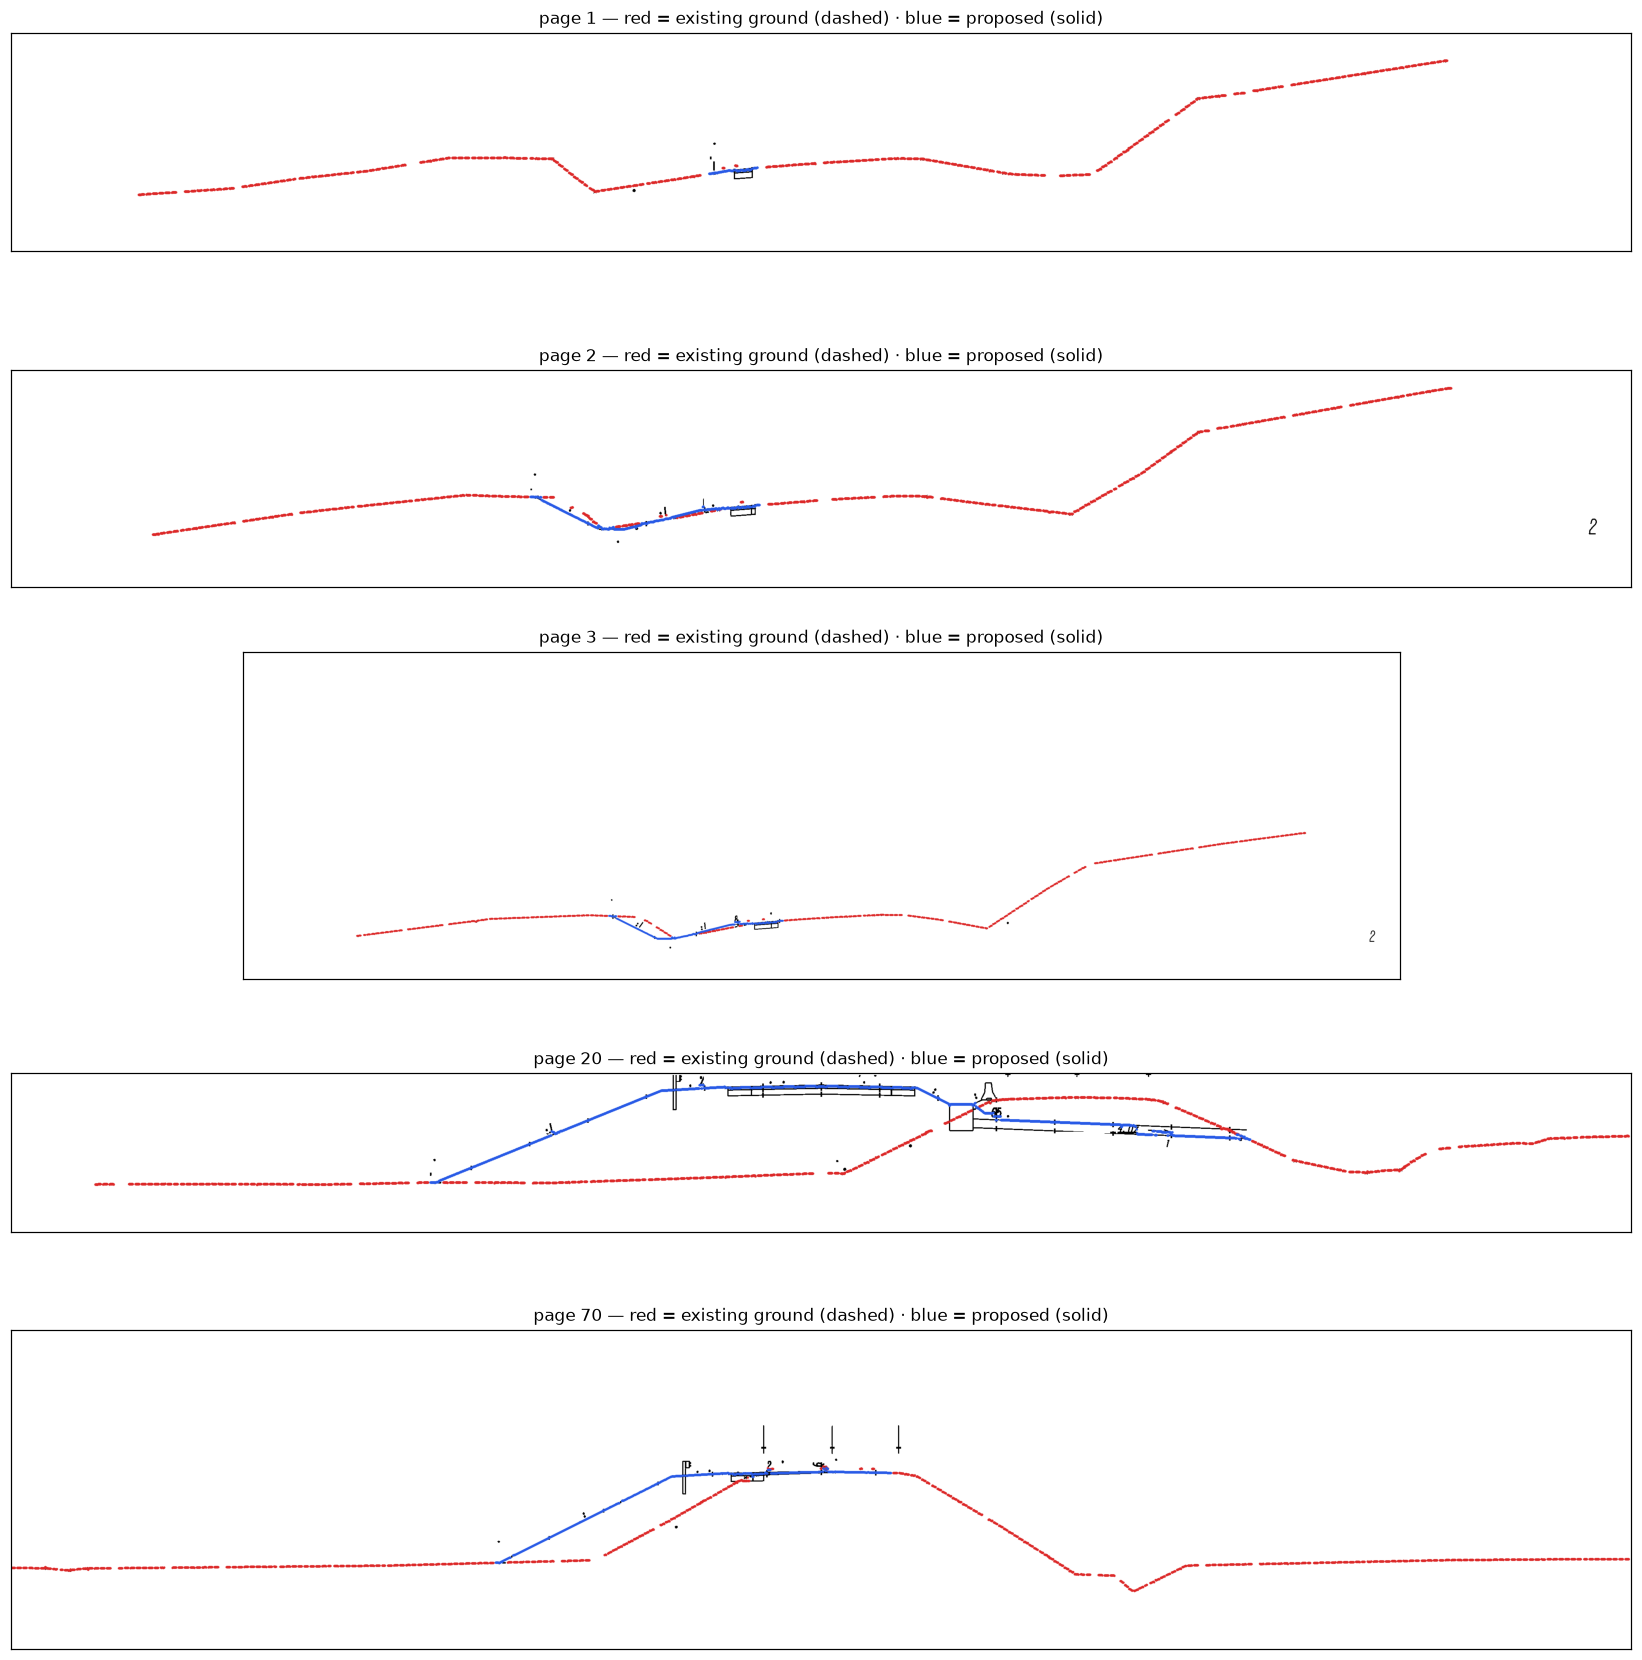

In [4]:
SEC = {p: Section(p, f) for p, f in PAGE_FILES.items()}
display(pd.DataFrame([s.summary() for s in SEC.values()]).set_index("page"))

fig, axes = plt.subplots(len(SEC), 1, figsize=(15, 3.1*len(SEC)))
for ax, s in zip(np.atleast_1d(axes), SEC.values()):
    vis = cv2.cvtColor(255 - s.roi*255, cv2.COLOR_GRAY2BGR)
    for x, y in s.ground_px.items(): cv2.circle(vis, (x, int(y)), 3, (220, 40, 40), -1)
    for x, y in s.design_px.items(): cv2.circle(vis, (x, int(y)), 3, (40, 90, 230), -1)
    ax.imshow(vis); ax.set_title(f"page {s.page} — red = existing ground (dashed) · blue = proposed (solid)")
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.savefig(f"{OUT}/qc_traces.png", dpi=120); plt.show()

In [5]:
diag = pd.DataFrame([s.summary() for s in SEC.values()]).set_index("page")
display(diag[["datum_src", "glyphs_removed", "spikes_g", "spikes_d",
              "max_gap_g_ft", "max_gap_d_ft", "trimmed"]])
for s in SEC.values():
    for t_ in s.trimmed:
        print(f"page {s.page}: trimmed {t_['side']} tail {t_['x_from']:+.1f}..{t_['x_to']:+.1f} ft "
              f"({t_['run_ft']} ft long, {t_['depth_ft']} ft below existing) - buried service, not a surface")

,datum_src,glyphs_removed,spikes_g,spikes_d,max_gap_g_ft,max_gap_d_ft,trimmed
page,,,,,,,
1,OCR consensus 10/10,56,0,0,2.7,0.3,0
2,OCR consensus 13/16,65,1,3,2.9,0.3,0
3,OCR consensus 10/16,69,0,0,3.3,0.3,0
20,OCR consensus 5/8,77,0,19,2.6,0.3,1
70,OCR consensus 20/27,79,8,7,8.8,0.5,0


page 20: trimmed right tail +26.9..+73.5 ft (45.2 ft long, 6.08 ft below existing) - buried service, not a surface


In [6]:
rows = []
for s in SEC.values():
    n_sq = (s.Rx - s.Lx) / s.pitch
    rows.append(dict(page=s.page, lattice_pitch_px=s.pitch,
                     axis_span_px=round(s.Rx - s.Lx, 1),
                     squares=round(n_sq, 3), squares_err=round(abs(n_sq - round(n_sq)), 4),
                     px_per_ft=round(s.ppf, 4), ft_per_square=round(s.span_ft / n_sq, 3),
                     datum_const=round(s.datum, 3), ocr_inliers=f"{s.ocr_inliers}/{s.ocr_total}"))
chk = pd.DataFrame(rows).set_index("page"); display(chk)
assert (chk.squares_err < 0.02).all(), "axis span is not a whole number of grid squares"
assert np.allclose(chk.ft_per_square, GRID_FT, atol=0.02), "grid square != 10 ft"
print("calibration consistent: 1 grid square = 10.00 ft, horizontal and vertical scales identical")

,lattice_pitch_px,axis_span_px,squares,squares_err,px_per_ft,ft_per_square,datum_const,ocr_inliers
page,,,,,,,,
1,144.0,4031.0,27.993,0.0069,14.3964,10.002,688.083,10/10
2,144.0,4031.0,27.993,0.0069,14.3964,10.002,688.090,13/16
3,144.0,4031.0,27.993,0.0069,14.3964,10.002,722.222,10/16
20,144.0,4031.0,27.993,0.0069,14.3964,10.002,668.090,5/8
70,144.0,4319.0,29.993,0.0069,14.3967,10.002,682.222,20/27


calibration consistent: 1 grid square = 10.00 ft, horizontal and vertical scales identical


In [7]:
SUBDIV     = 1
SUPERSAMPLE = 4

def between_mask(s, ss=1):
    """Binary rasters of the FILL and CUT regions, at `ss` x native resolution.
    Rows/cols are in supersampled ROI pixel space."""
    H, W = s.H*ss, s.W*ss
    cols = np.arange(W)
    G = np.interp(cols/ss, np.arange(s.W), s.G) * ss
    D = np.interp(cols/ss, np.arange(s.W), s.D) * ss
    ok = ~np.isnan(G) & ~np.isnan(D)
    rr  = np.arange(H)[:, None]
    lo  = np.where(ok, np.minimum(G, D), np.inf)
    hi  = np.where(ok, np.maximum(G, D), -np.inf)
    band = (rr >= lo) & (rr < hi)
    fill = band & (D < G)
    cut  = band & (D > G)
    return fill, cut

def cell_ledger(s, subdiv=SUBDIV, ss=SUPERSAMPLE):
    """Cut into grid cells, measure each, note it down."""
    fill, cut = between_mask(s, ss)
    px_ft2 = 1.0 / (s.ppf*ss)**2

    step_px = s.pitch / subdiv * ss
    cx_ss = (s.cx - s.rx0) * ss
    ci0 = int(np.floor((0 - cx_ss) / step_px)); ci1 = int(np.ceil((fill.shape[1] - cx_ss) / step_px))
    cy_ss = (s.row_of(s.datum)) * ss
    rj0 = int(np.floor((0 - cy_ss) / step_px)); rj1 = int(np.ceil((fill.shape[0] - cy_ss) / step_px))

    rows = []
    for i in range(ci0, ci1):
        x0p, x1p = cx_ss + i*step_px, cx_ss + (i+1)*step_px
        c0, c1 = int(max(0, np.floor(x0p))), int(min(fill.shape[1], np.ceil(x1p)))
        if c1 <= c0: continue
        fcol, ccol = fill[:, c0:c1], cut[:, c0:c1]
        if not (fcol.any() or ccol.any()): continue
        for j in range(rj0, rj1):
            y0p, y1p = cy_ss + j*step_px, cy_ss + (j+1)*step_px
            r0, r1 = int(max(0, np.floor(y0p))), int(min(fill.shape[0], np.ceil(y1p)))
            if r1 <= r0: continue
            nf = int(fcol[r0:r1].sum()); nc = int(ccol[r0:r1].sum())
            if nf == 0 and nc == 0: continue
            rows.append(dict(page=s.page, cell_i=i, cell_j=j,
                             x_from=round(s.x_ft(c0/ss), 2), x_to=round(s.x_ft(c1/ss), 2),
                             elev_top=round(s.elev(r0/ss), 2), elev_bot=round(s.elev(r1/ss), 2),
                             fill_ft2=nf*px_ft2, cut_ft2=nc*px_ft2))
    return pd.DataFrame(rows)

LEDGER = {p: cell_ledger(s) for p, s in SEC.items()}
for p, d in LEDGER.items():
    print(f"page {p}: {len(d)} non-empty cells")
display(LEDGER[2].head(12))

page 1: 1 non-empty cells
page 2: 5 non-empty cells
page 3: 5 non-empty cells
page 20: 18 non-empty cells
page 70: 14 non-empty cells


,page,cell_i,cell_j,x_from,x_to,elev_top,elev_bot,fill_ft2,cut_ft2
0,2,-5,2,-50.01,-40.01,668.09,658.08,0.039504,0.583213
1,2,-5,3,-50.01,-40.01,658.08,648.08,0.000000,9.207161
2,2,-4,3,-40.01,-30.01,658.08,648.08,0.048249,3.744141
3,2,-3,3,-30.01,-20.00,658.08,648.08,2.161566,0.846171
4,2,-2,3,-20.00,-10.00,658.08,648.08,0.706851,2.316567


In [8]:
tot = []
for p, d in LEDGER.items():
    tot.append(dict(page=p, cells=len(d),
                    fill_ft2=d.fill_ft2.sum(), cut_ft2=d.cut_ft2.sum(),
                    net_ft2=d.fill_ft2.sum() - d.cut_ft2.sum()))
TOT1 = pd.DataFrame(tot).set_index("page").round(3)
display(TOT1)
for p, d in LEDGER.items():
    d.to_csv(f"{OUT}/cells_page{p:03d}.csv", index=False)
TOT1.to_csv(f"{OUT}/totals_approach1.csv")
print("ledgers written to", OUT)

,cells,fill_ft2,cut_ft2,net_ft2
page,,,,
1,1,0.000,3.300,-3.300
2,5,2.956,16.697,-13.741
3,5,6.290,32.080,-25.790
20,18,964.590,0.002,964.588
70,14,249.018,12.752,236.265


ledgers written to outputs


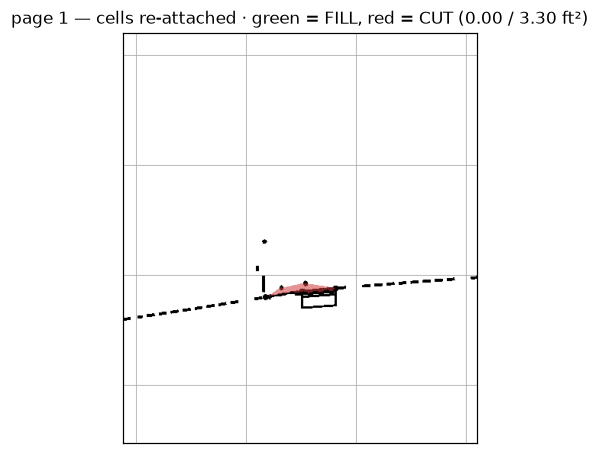

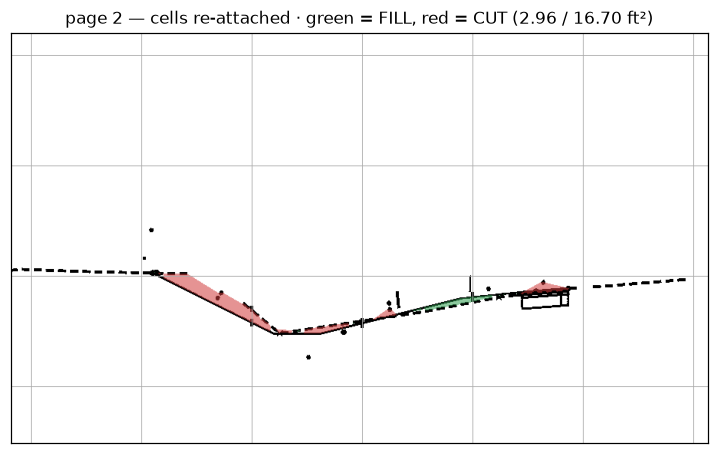

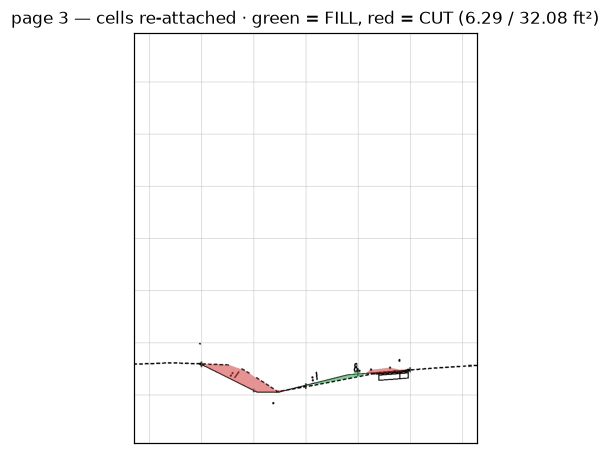

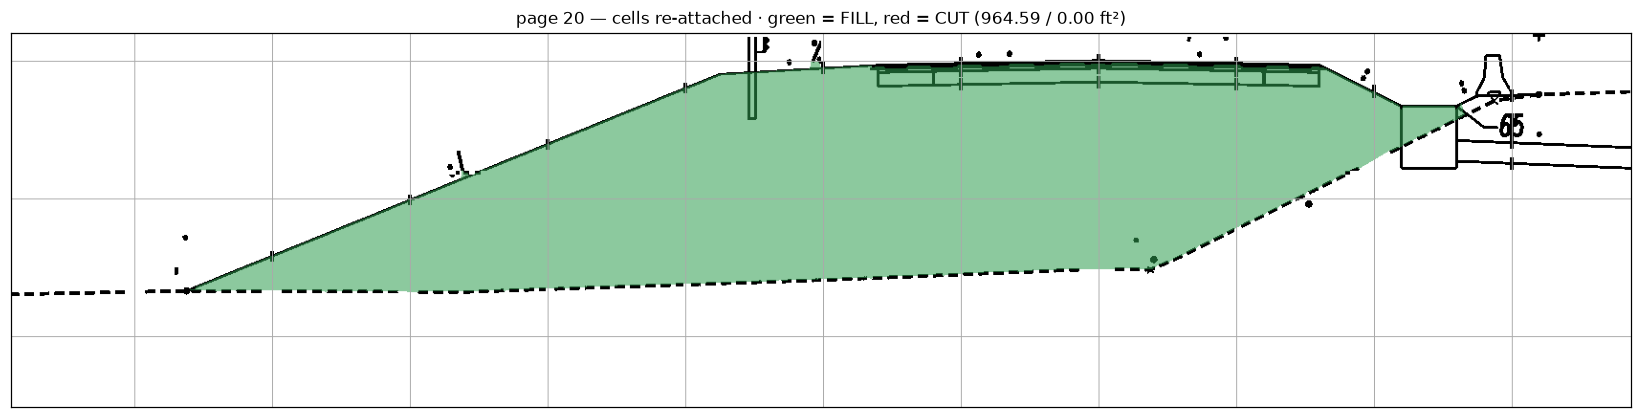

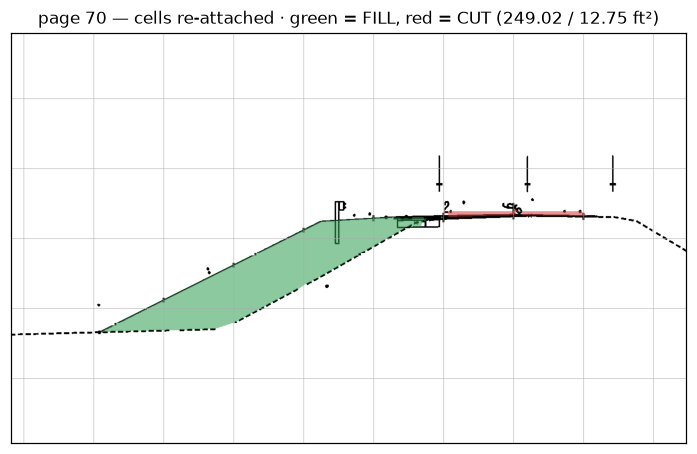

In [9]:
def colour_composite(s, ledger, subdiv=SUBDIV, ss=SUPERSAMPLE, alpha=0.55):
    fill, cut = between_mask(s, ss)
    fill = cv2.resize(fill.astype(np.uint8), (s.W, s.H), interpolation=cv2.INTER_AREA).astype(bool)
    cut  = cv2.resize(cut.astype(np.uint8),  (s.W, s.H), interpolation=cv2.INTER_AREA).astype(bool)

    base = cv2.cvtColor(255 - s.roi*255, cv2.COLOR_GRAY2BGR).astype(float)
    lay  = base.copy()
    lay[fill] = (79, 158, 46)
    lay[cut]  = (59, 59, 209)
    out = np.where((fill | cut)[..., None], (1-alpha)*base + alpha*lay, base).astype(np.uint8)

    step = s.pitch / subdiv
    cx = s.cx - s.rx0
    for i in range(int(-cx/step)-1, int((s.W-cx)/step)+2):
        X = int(round(cx + i*step))
        if 0 <= X < s.W: cv2.line(out, (X, 0), (X, s.H-1), (170, 170, 170), 1)
    cy = s.row_of(s.datum)
    for j in range(int(-cy/step)-1, int((s.H-cy)/step)+2):
        Y = int(round(cy + j*step))
        if 0 <= Y < s.H: cv2.line(out, (0, Y), (s.W-1, Y), (170, 170, 170), 1)
    return out

for p, s in SEC.items():
    img = colour_composite(s, LEDGER[p])
    cv2.imwrite(f"{OUT}/coloured_page{p:03d}.png", img)
    ov = s.overlap
    c0, c1 = np.where(ov)[0].min(), np.where(ov)[0].max()
    pad = int(1.2*s.ppf*10)
    fig, ax = plt.subplots(figsize=(15, 4.2))
    ax.imshow(img[:, max(0, c0-pad):min(s.W, c1+pad)][:, :, ::-1])
    ax.set_title(f"page {p} — cells re-attached · green = FILL, red = CUT "
                 f"({TOT1.loc[p,'fill_ft2']:.2f} / {TOT1.loc[p,'cut_ft2']:.2f} ft²)")
    ax.set_xticks([]); ax.set_yticks([]); plt.tight_layout(); plt.show()